In [68]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [70]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

print(df.head())
print(df.shape)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [71]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None
              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000    

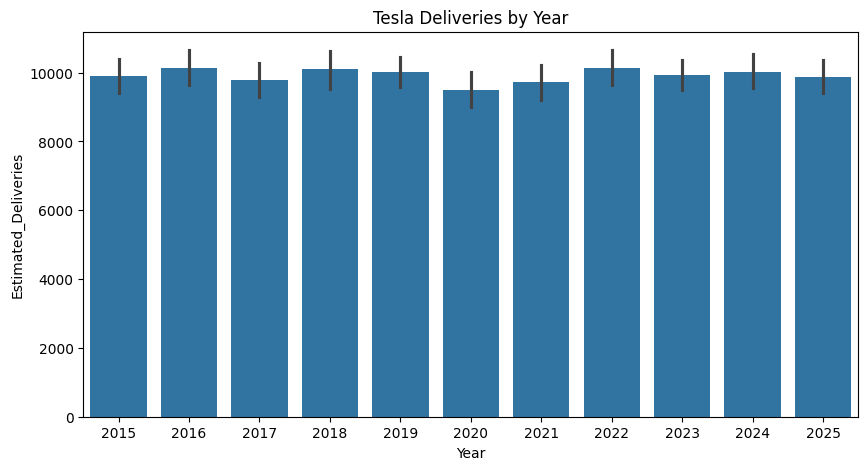

In [72]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries by Year")
plt.show()

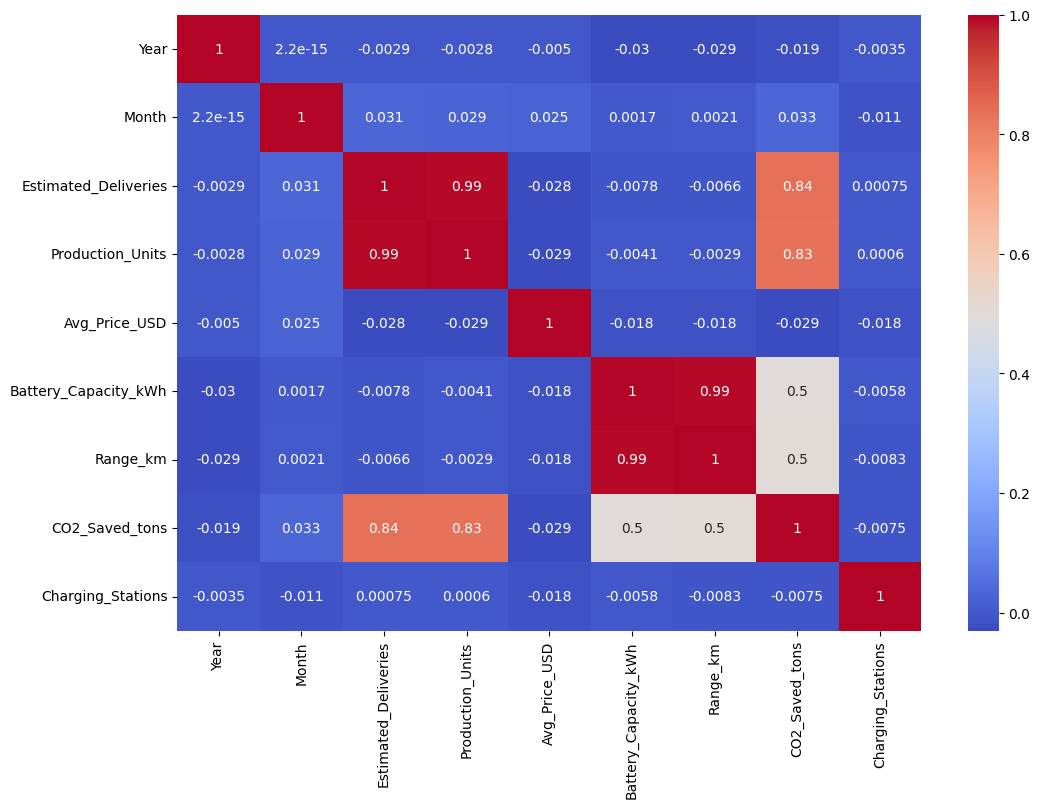

In [73]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

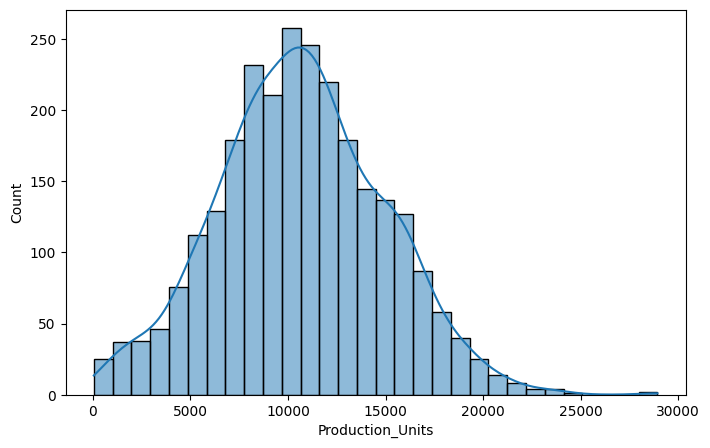

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Production_Units'],
    bins=30,
    kde=True
)

plt.show()

In [75]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

df = df.sort_values('Date')

In [76]:
df['Lag_Production'] = df['Production_Units'].shift(1)

In [77]:
df['Rolling_Production'] = (
    df['Production_Units']
    .rolling(window=3)
    .mean()
)

In [78]:
df = df.dropna()

In [79]:
encoder = LabelEncoder()

df['Region'] = encoder.fit_transform(df['Region'])
df['Model'] = encoder.fit_transform(df['Model'])
df['Source_Type'] = encoder.fit_transform(df['Source_Type'])

In [80]:
X = df.drop(
    ['Estimated_Deliveries','Date'],
    axis=1
)

y = df['Estimated_Deliveries']

In [81]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [82]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

predictions = rf.predict(X_test)

In [83]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 325.48003787878787
RMSE : 404.7397806045112
R2 : 0.9876789980334769


In [ ]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.show()